In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import re
from tqdm.auto import tqdm

import os
import urllib.request
import zipfile

from datasets import load_dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from dotenv import load_dotenv
load_dotenv()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

d:\App\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [5]:
from abc import abstractmethod, ABC
import py_vncorenlp
os.environ['JAVA_HOME'] = r'D:\App\Java\jdk-24'


class Tokenizer(ABC):
    @abstractmethod
    def tokenize(self, text):
        return print("Tokenizer is not implemented yet.")

class VnCoreNLPTokenizer(Tokenizer):
    def __init__(self, save_dir: str = "../VnCoreNLP"):

        self.save_dir = os.path.abspath(save_dir)

        if os.path.exists(self.save_dir):
            print(f"VnCoreNLP was found at {self.save_dir}")
        else:
            print(f"Dir {self.save_dir} was not found. Automatically download VnCoreNLP.")
            self._download_and_extract()
            
        self.rdrsegmenter = py_vncorenlp.VnCoreNLP(
            annotators=["wseg"], 
            save_dir=self.save_dir,
        )

    def _download_and_extract(self):
        # url = "https://github.com/vncorenlp/VnCoreNLP/archive/master.zip"
        # zip_path = "VnCoreNLP_master.zip"

        # try:
        #     urllib.request.urlretrieve(url, zip_path)

        #     print("⏳ Đang giải nén dữ liệu...")
        #     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        #         zip_ref.extractall(".")

        #     extracted_folder = "VnCoreNLP-master"
            
        #     if os.path.exists(extracted_folder):
        #         os.rename(extracted_folder, self.save_dir)
                
        #     print("✅ Tải và cài đặt VnCoreNLP thành công!")

        # except Exception as e:
        #     print(f"❌ Có lỗi xảy ra trong quá trình tải: {e}")
            
        # finally:
        #     if os.path.exists(zip_path):
        #         os.remove(zip_path)

        py_vncorenlp.download_model(self.save_dir)
        

    def tokenize(self, text):
        segmented = self.rdrsegmenter.word_segment(text)
        if isinstance(segmented, list):
            return " ".join(segmented)
        return segmented
    
class UndertheseaTokenizer(Tokenizer):
    def __init__(self):
        from underthesea import word_tokenize
        self.word_tokenize = word_tokenize

    def tokenize(self, text):
        tokens = self.word_tokenize(text, format="text")
        if isinstance(tokens, list):
            return " ".join(tokens)
        return tokens

In [3]:
class TextPreprocessor:
    def __init__(self, teencode_dict: dict = None, tokenizer: Tokenizer = None):
        self.teencode_dict = teencode_dict if teencode_dict else {}
        self.tokenizer = tokenizer if tokenizer else UndertheseaTokenizer()

    def remove_noise(self, text):
        text = str(text).lower()
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'[^\w\s_áàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ\.,]', ' ', text) 
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def normalize_teencode(self, text):
        words = text.split()
        normalized_words = [self.teencode_dict.get(w, w) for w in words]
        return ' '.join(normalized_words)

    def handle_lengthening(self, text):
        return re.sub(r'([auioeyđáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ])\1+', r'\1', text)

    def segment_words(self, text):
        return self.tokenizer.tokenize(text)

    def process(self, text):
        if not text or not isinstance(text, str):
            return ""
        text = self.remove_noise(text)
        text = self.handle_lengthening(text)
        text = self.normalize_teencode(text)
        text = self.segment_words(text)
        return text

In [6]:
vncore = VnCoreNLPTokenizer()
uts = UndertheseaTokenizer()

preprocessor = TextPreprocessor(tokenizer=vncore)

VnCoreNLP was found at d:\Code\Python\Project\StudentFeedback\VnCoreNLP


In [7]:
preprocessor.process("abc xyz.")

'abc xyz .'

In [5]:
dataset = load_dataset("uitnlp/vietnamese_students_feedback", revision="refs/convert/parquet")
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df_val = pd.DataFrame(dataset['validation'])

In [6]:
df_train['clean_sentence'] = df_train['sentence'].apply(preprocessor.process)
df_test['clean_sentence'] = df_test['sentence'].apply(preprocessor.process)
df_val['clean_sentence'] = df_val['sentence'].apply(preprocessor.process)

display(df_train[['sentence', 'clean_sentence', 'sentiment', 'topic']].head())
display(df_test[['sentence', 'clean_sentence', 'sentiment', 'topic']].head())
display(df_val[['sentence', 'clean_sentence', 'sentiment', 'topic']].head())

,sentence,clean_sentence,sentiment,topic
0,slide giáo trình đầy đủ .,slide giáo_trình đầy_đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .","nhiệt_tình giảng_dạy , gần_gũi với sinh_viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy_đủ full điểm chuyên_cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...","thầy giảng bài hay , có nhiều bài_tập ví_dụ ng...",2,0


,sentence,clean_sentence,sentiment,topic
0,nói tiếng anh lưu loát .,nói tiếng anh lưu_loát .,2,0
1,giáo viên rất vui tính .,giáo_viên rất vui_tính .,2,0
2,cô max có tâm .,cô max có tâm .,2,0
3,"giảng bài thu hút , dí dỏm .","giảng bài thu_hút , dí_dỏm .",2,0
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...","giáo_viên không giảng_dạy kiến_thức , hướng_dẫ...",0,0


,sentence,clean_sentence,sentiment,topic
0,giáo trình chưa cụ thể .,giáo_trình chưa cụ_thể .,0,1
1,giảng buồn ngủ .,giảng buồn_ngủ .,0,0
2,"giáo viên vui tính , tận tâm .","giáo_viên vui_tính , tận_tâm .",2,0
3,"giảng viên nên giao bài tập nhiều hơn , chia n...","giảng_viên nên giao bài_tập nhiều hơn , chia n...",0,0
4,"giảng viên cần giảng bài chi tiết hơn , đi sâu...","giảng_viên cần giảng bài chi_tiết hơn , đi_sâu...",0,0


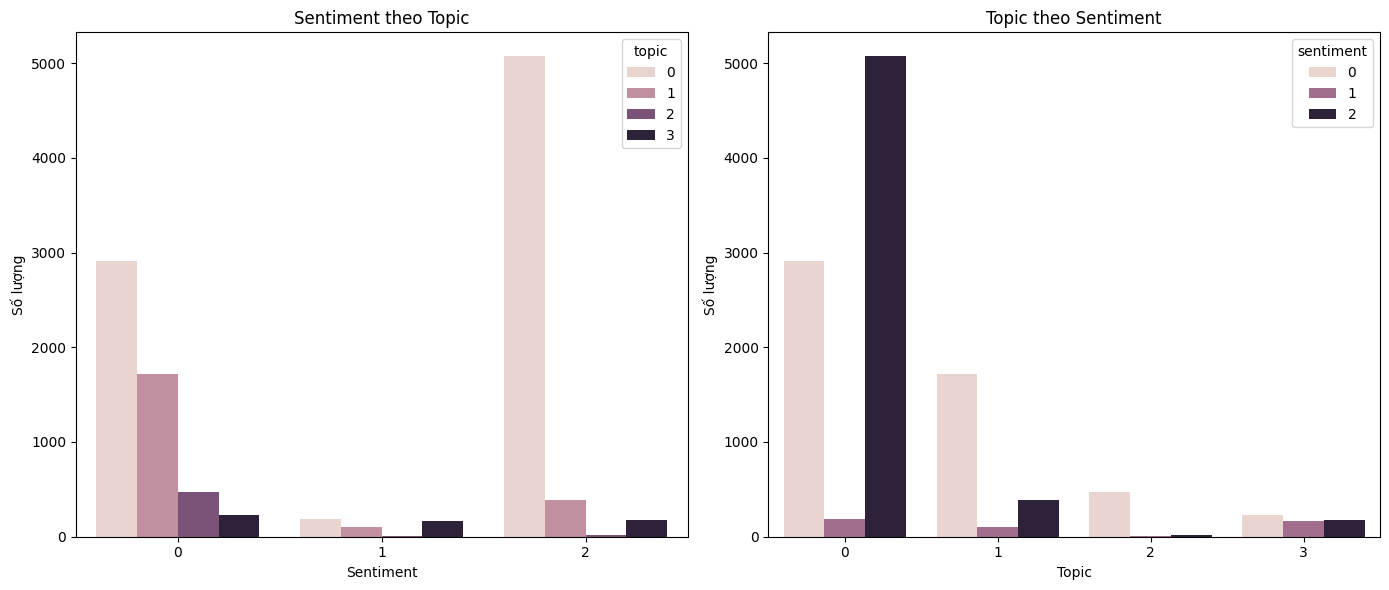

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df_train, x='sentiment', hue='topic', ax=axes[0])
axes[0].set_title('Sentiment theo Topic')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Số lượng')

sns.countplot(data=df_train, x='topic', hue='sentiment', ax=axes[1])
axes[1].set_title('Topic theo Sentiment')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

[90%] seq len <= 21 token
[95%] seq len <= 27 token
[97%] seq len <= 31 token
[99%] seq len <= 42 token


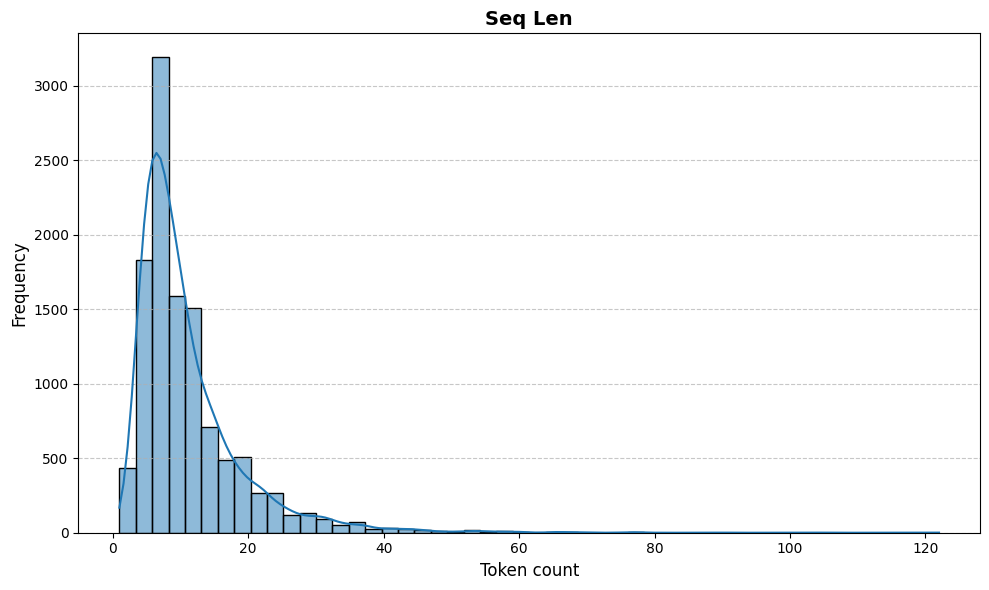

In [8]:
# Plot graph tính seq len của các data
df_train['word_count'] = df_train['clean_sentence'].apply(lambda x: len(str(x).split()))

for q in [0.90, 0.95, 0.97,0.99]:
    val = df_train['word_count'].quantile(q)
    print(f"[{q*100:.0f}%] seq len <= {val:.0f} token")

# Vẽ biểu đồ Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_train['word_count'], bins=50, kde=True, color='#1f77b4', edgecolor='black')

plt.title('Seq Len', fontsize=14, fontweight='bold')
plt.xlabel('Token count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
class FeedbackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len):
        super().__init__()
        self.texts = df['clean_sentence'].tolist()
        self.sentiments = df['sentiment'].tolist()
        self.topics = df['topic'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, index):
        text = str(self.texts[index])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'topic': torch.tensor(self.topics[index], dtype=torch.long),
            'sentiment': torch.tensor(self.sentiments[index], dtype=torch.long)
        }

MAX_LEN = 31
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)
train_dataset = FeedbackDataset(df_train, tokenizer, max_len=MAX_LEN)
val_dataset = FeedbackDataset(df_val, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class MultiTask(nn.Module):
    def __init__(self, dropout: str = .3, tokenizer = None, preprocessor = None, max_len = 31):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.bert = AutoModel.from_pretrained("vinai/phobert-base")

        self.topic = nn.Linear(768, 4)
        self.sentiment = nn.Linear(768, 3)

        self.tokenizer = tokenizer
        self.preprocessor = preprocessor
        self.max_len = max_len

        self.topic_mapping = {
            0: "Cơ sở vật chất", 
            1: "Giảng viên", 
            2: "Chương trình đào tạo", 
            3: "Khác",
        }
        self.sent_mapping = {
            0: "Tích cực", 
            1: "Tiêu cực", 
            2: "Trung tính"
        }

    def forward(self, ids, mask):
        outputs = self.bert(
            input_ids=ids,
            attention_mask=mask,    
        )

        pooled_outputs = outputs.last_hidden_state[:, 0, :]
        pooled_outputs = self.dropout(pooled_outputs)

        topic_logits = self.topic(pooled_outputs)
        sentiment_logits = self.sentiment(pooled_outputs)

        return topic_logits, sentiment_logits
    
    
model = MultiTask().to(device)
print(model)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 52910.71it/s]
[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultiTask(
  (dropout): Dropout(p=0.3, inplace=False)
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(258, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=Tr

In [11]:
from sklearn.utils import compute_class_weight

sentiment_weights = compute_class_weight(class_weight="balanced", classes=np.unique(df_train['sentiment']), y=df_train['sentiment'])
tensor_sentiment_weights = torch.tensor(sentiment_weights, dtype=torch.float32).to(device)

topic_weights = compute_class_weight(class_weight="balanced", classes=np.unique(df_train['topic']), y=df_train['topic'])
tensor_topic_weights = torch.tensor(topic_weights, dtype=torch.float32).to(device)

loss_fn_sentiment = nn.CrossEntropyLoss(weight=tensor_sentiment_weights)
loss_fn_topic = nn.CrossEntropyLoss(weight=tensor_topic_weights)

In [12]:
from sklearn.metrics import f1_score

EPOCHS = 10

history = {
    'train_loss': [], 'val_loss': [],
    'train_topic_loss': [], 'val_topic_loss': [],
    'train_sentiment_loss': [], 'val_sentiment_loss': [],
    'val_topic_f1': [], 'val_sentiment_f1': []
}

for epoch in range(EPOCHS):
    # ========================================
    #              TRAINING
    # ========================================
    model.train()
    total_train_loss = 0
    total_train_topic = 0
    total_train_sentiment = 0
    
    train_loop = tqdm(train_loader, leave=False, total=len(train_loader), desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    
    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        topics = batch['topic'].to(device)
        sentiments = batch['sentiment'].to(device)
        
        optimizer.zero_grad()
        
        topic_logits, sentiment_logits = model(input_ids, attention_mask)
        
        loss_topic = loss_fn_topic(topic_logits, topics)
        loss_sentiment = loss_fn_sentiment(sentiment_logits, sentiments)
        loss = loss_topic + loss_sentiment
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        total_train_topic += loss_topic.item()
        total_train_sentiment += loss_sentiment.item()

        train_loop.set_postfix(loss=loss.item())
        
    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_topic = total_train_topic / len(train_loader)
    avg_train_sentiment = total_train_sentiment / len(train_loader)

    # ========================================
    #              VALIDATION
    # ========================================
    model.eval()
    total_val_loss = 0
    total_val_topic = 0
    total_val_sentiment = 0

    val_topic_preds, val_topic_targets = [], []
    val_sentiment_preds, val_sentiment_targets = [], []
    
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
    
    with torch.no_grad():
        for batch in val_loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            topics = batch['topic'].to(device)
            sentiments = batch['sentiment'].to(device)
            
            topic_logits, sentiment_logits = model(input_ids, attention_mask)
            
            loss_topic = loss_fn_topic(topic_logits, topics)
            loss_sentiment = loss_fn_sentiment(sentiment_logits, sentiments)
            loss = loss_topic + loss_sentiment
            
            total_val_loss += loss.item()
            total_val_topic += loss_topic.item()
            total_val_sentiment += loss_sentiment.item()
            
            val_topic_preds.extend(torch.argmax(topic_logits, dim=1).cpu().numpy())
            val_topic_targets.extend(topics.cpu().numpy())
            
            val_sentiment_preds.extend(torch.argmax(sentiment_logits, dim=1).cpu().numpy())
            val_sentiment_targets.extend(sentiments.cpu().numpy())
            
    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_topic = total_val_topic / len(val_loader)
    avg_val_sentiment = total_val_sentiment / len(val_loader)

    topic_f1 = f1_score(val_topic_targets, val_topic_preds, average='macro')
    sent_f1 = f1_score(val_sentiment_targets, val_sentiment_preds, average='macro')

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    history['train_topic_loss'].append(avg_train_topic)
    history['val_topic_loss'].append(avg_val_topic)
    
    history['train_sentiment_loss'].append(avg_train_sentiment)
    history['val_sentiment_loss'].append(avg_val_sentiment)
    
    history['val_topic_f1'].append(topic_f1)
    history['val_sentiment_f1'].append(sent_f1)
    
    print(f"\n--- Epoch {epoch+1} ---")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Topic F1 (Macro): {topic_f1:.4f} | Sentiment F1 (Macro): {sent_f1:.4f}\n")

Epoch 1/10 [Val]: 100%|██████████| 50/50 [00:01<00:00, 27.97it/s]                



--- Epoch 1 ---
Train Loss: 1.3055 | Val Loss: 0.9006
Topic F1 (Macro): 0.7628 | Sentiment F1 (Macro): 0.8169



Epoch 2/10 [Val]: 100%|██████████| 50/50 [00:01<00:00, 32.92it/s]                



--- Epoch 2 ---
Train Loss: 0.7602 | Val Loss: 0.8286
Topic F1 (Macro): 0.7442 | Sentiment F1 (Macro): 0.8134



Epoch 3/10 [Val]: 100%|██████████| 50/50 [00:01<00:00, 28.80it/s]                


...


--- Epoch 8 ---
Train Loss: 0.2620 | Val Loss: 1.3895
Topic F1 (Macro): 0.7855 | Sentiment F1 (Macro): 0.8403



Epoch 9/10 [Val]: 100%|██████████| 50/50 [00:01<00:00, 33.58it/s]                 



--- Epoch 9 ---
Train Loss: 0.2248 | Val Loss: 1.3727
Topic F1 (Macro): 0.7943 | Sentiment F1 (Macro): 0.8741



Epoch 10/10 [Val]: 100%|██████████| 50/50 [00:01<00:00, 28.67it/s]                 


--- Epoch 10 ---
Train Loss: 0.2089 | Val Loss: 1.4418
Topic F1 (Macro): 0.7773 | Sentiment F1 (Macro): 0.8615



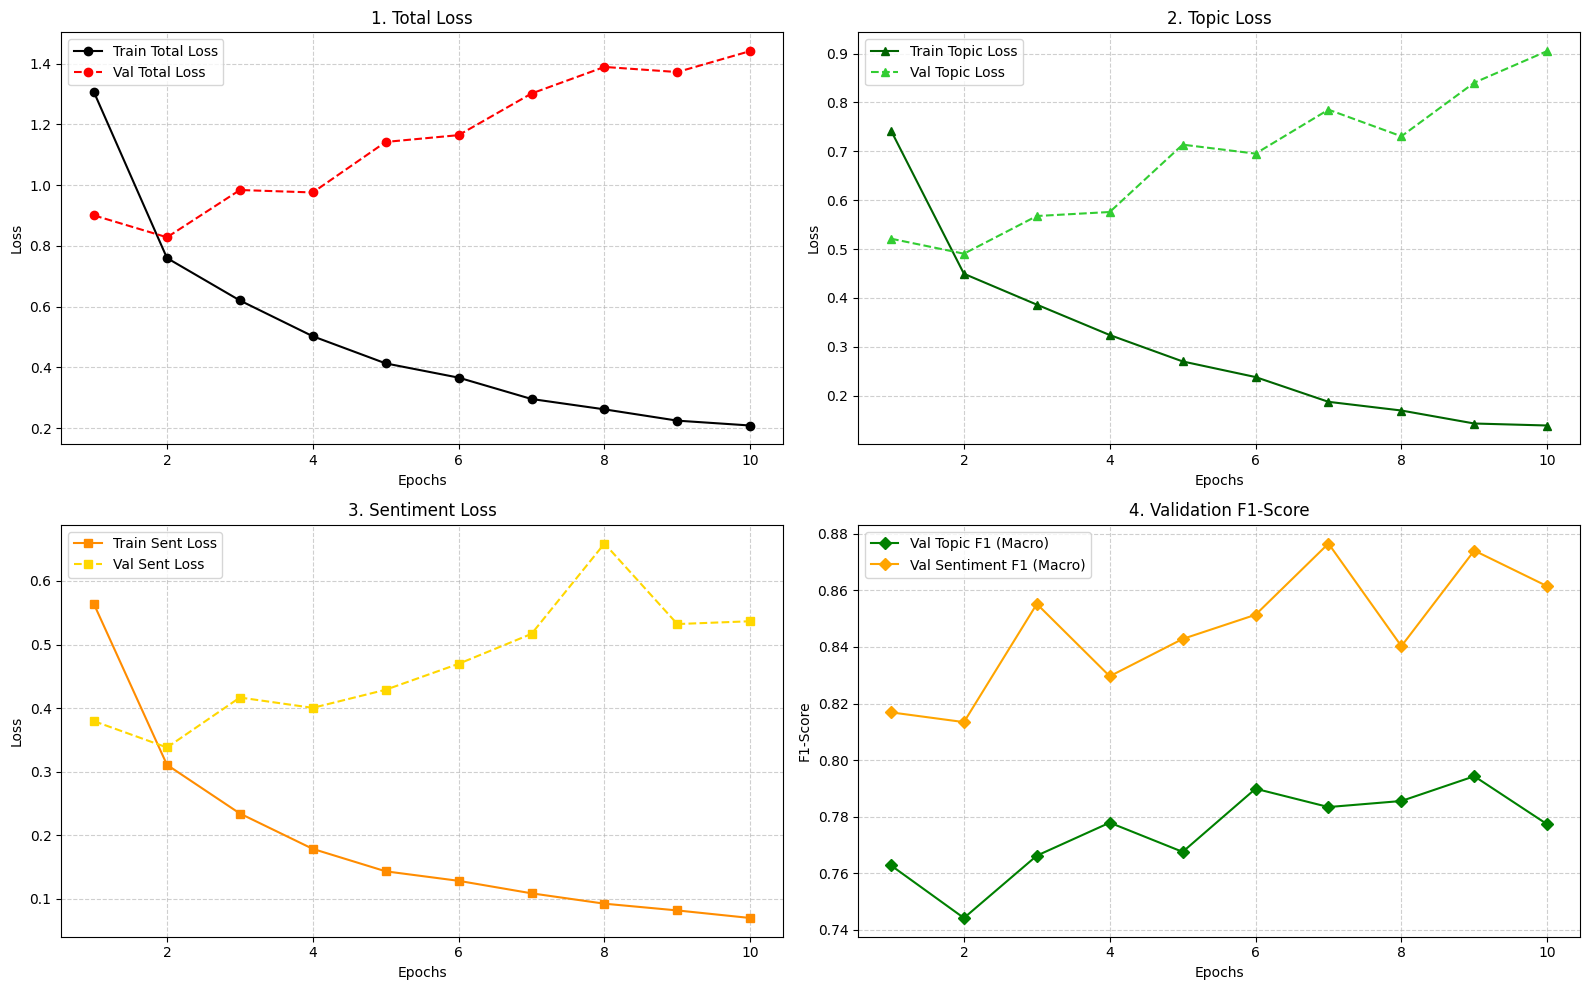

In [13]:
# Tạo layout 2x2 (2 hàng, 2 cột) để hiển thị đầy đủ và rõ ràng nhất
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
epochs_range = range(1, EPOCHS + 1)

# [Góc trên trái] Biểu đồ 1: Tổng quan Total Loss (Train vs Val)
axes[0, 0].plot(epochs_range, history['train_loss'], label='Train Total Loss', marker='o', color='black')
axes[0, 0].plot(epochs_range, history['val_loss'], label='Val Total Loss', marker='o', color='red', linestyle='--')
axes[0, 0].set_title('1. Total Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# [Góc trên phải] Biểu đồ 2: Topic Loss (Train vs Val)
axes[0, 1].plot(epochs_range, history['train_topic_loss'], label='Train Topic Loss', marker='^', color='darkgreen')
axes[0, 1].plot(epochs_range, history['val_topic_loss'], label='Val Topic Loss', marker='^', color='limegreen', linestyle='--')
axes[0, 1].set_title('2. Topic Loss')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# [Góc dưới trái] Biểu đồ 3: Sentiment Loss (Train vs Val)
axes[1, 0].plot(epochs_range, history['train_sentiment_loss'], label='Train Sent Loss', marker='s', color='darkorange')
axes[1, 0].plot(epochs_range, history['val_sentiment_loss'], label='Val Sent Loss', marker='s', color='gold', linestyle='--')
axes[1, 0].set_title('3. Sentiment Loss')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# [Góc dưới phải] Biểu đồ 4: F1-Score Curve (Đánh giá hiệu năng)
axes[1, 1].plot(epochs_range, history['val_topic_f1'], label='Val Topic F1 (Macro)', marker='D', color='green')
axes[1, 1].plot(epochs_range, history['val_sentiment_f1'], label='Val Sentiment F1 (Macro)', marker='D', color='orange')
axes[1, 1].set_title('4. Validation F1-Score')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [14]:
test_dataset = FeedbackDataset(df_test, tokenizer, max_len=45)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def evaluate_on_test(model, test_loader, device):
    print("Đang tiến hành đánh giá trên tập Test...")
    model.eval()
    
    test_topic_preds, test_topic_targets = [], []
    test_sent_preds, test_sent_targets = [], []
    
    test_loop = tqdm(test_loader, desc="Testing")
    
    with torch.no_grad():
        for batch in test_loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            topics = batch['topic'].to(device)
            sentiments = batch['sentiment'].to(device)
            
            # Forward pass
            topic_logits, sentiment_logits = model(input_ids, attention_mask)
            
            # Lấy dự đoán
            test_topic_preds.extend(torch.argmax(topic_logits, dim=1).cpu().numpy())
            test_topic_targets.extend(topics.cpu().numpy())
            
            test_sent_preds.extend(torch.argmax(sentiment_logits, dim=1).cpu().numpy())
            test_sent_targets.extend(sentiments.cpu().numpy())
            
    # In báo cáo chi tiết cho từng Task
    print("\n" + "="*40)
    print("BÁO CÁO PHÂN LOẠI TOPIC (CHỦ ĐỀ)")
    print("="*40)
    print(classification_report(test_topic_targets, test_topic_preds, digits=4))
    
    print("\n" + "="*40)
    print("BÁO CÁO PHÂN LOẠI SENTIMENT (CẢM XÚC)")
    print("="*40)
    print(classification_report(test_sent_targets, test_sent_preds, digits=4))

# 3. Chạy thử nghiệm
# (Nếu bạn đã lưu file weights tốt nhất, nhớ load nó lên trước khi chạy hàm này nhé!)
# Ví dụ: model.load_state_dict(torch.load('best_model.pt'))

evaluate_on_test(model, test_loader, device)

Đang tiến hành đánh giá trên tập Test...


Testing: 100%|██████████| 99/99 [00:04<00:00, 24.73it/s]


BÁO CÁO PHÂN LOẠI TOPIC (CHỦ ĐỀ)
              precision    recall  f1-score   support

           0     0.9620    0.8843    0.9215      2290
           1     0.6626    0.8619    0.7492       572
           2     0.8824    0.9310    0.9060       145
           3     0.5366    0.5535    0.5449       159

    accuracy                         0.8658      3166
   macro avg     0.7609    0.8077    0.7804      3166
weighted avg     0.8829    0.8658    0.8708      3166


BÁO CÁO PHÂN LOẠI SENTIMENT (CẢM XÚC)
              precision    recall  f1-score   support

           0     0.9420    0.9574    0.9497      1409
           1     0.5789    0.5269    0.5517       167
           2     0.9558    0.9509    0.9533      1590

    accuracy                         0.9315      3166
   macro avg     0.8256    0.8118    0.8182      3166
weighted avg     0.9298    0.9315    0.9305      3166

